# プログラミング課題

`sc2025-sample.ipynb` を参考に，ファジィ制御を実装してください．

実際にプログラムを書いてもらいたいところには， **課題(n)** とタイトルをつけてあります．

pythonの基本的な構文を調べたい場合には，以下のサイトがおすすめです．

- https://www.javadrive.jp/python/
- https://www.tohoho-web.com/python/index.html
- https://note.nkmk.me/python/

## ファジィ制御で，車の速度制御を行う

ファジィ制御で，目標速度60km/hで走行する車の速度を制御することを考えます．

## ファジィルールの形

ファジィルールは，以下のような形となります．

> if "道路の勾配 is ○○" and "速度偏差 is △△" then "加速の大きさ is ☆☆"

前件部変数は2つ，後件部変数は1つです．

"道路の勾配 is ○○" は，車が走る道の勾配を-1から1の値で表します．

"速度偏差 is △△" は，車の現在速度と目標速度との差で，-60から50の値で表します．

"加速の大きさ is ☆☆" は，減速・加速を-10から10の値で表します．

## 三角型メンバーシップ関数の形

### 前件部 道路の勾配に対応する三角型メンバーシップ関数

道路の勾配に対応する三角型メンバーシップ関数は以下のような形とします．

メンバーシップ関数のグラフが見えない場合には，pythonのコードが書かれているセルで，`Shift + Enter` を押してください．

道路の勾配のファジィラベルは以下のことを意味します．

- N：下り坂
- Z0：平坦
- P：上り坂

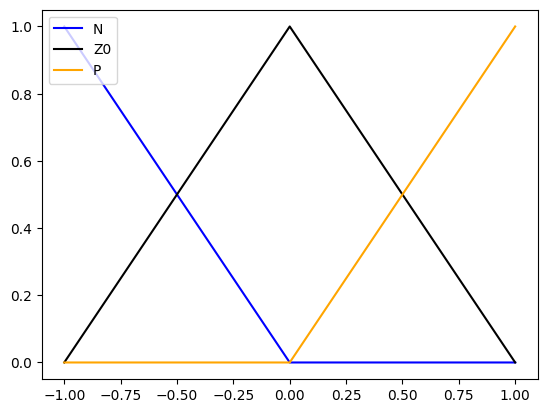

In [27]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
 
# 道路の勾配のメンバーシップ関数を描画する
slope = np.array([-1, 0, 1])

n = np.array([1, 0, 0])
plt_n = plt.plot(slope, n, color="blue")

z0 = np.array([0, 1, 0])
plt_z0 = plt.plot(slope, z0, color="black")

p = np.array([0, 0, 1])
plt_p = plt.plot(slope, p, color="orange")

plt.legend((plt_n[0], plt_z0[0], plt_p[0]), ("N", "Z0", "P"), loc=2)

# Shift + Enter を押してもメンバーシップ関数のグラフが表示されないときには，もう一度 Shift + Enter を押す

### 前件部 速度偏差に対応する三角型メンバーシップ関数

速度偏差に対応する三角型メンバーシップ関数は以下の形です．

メンバーシップ関数のグラフが見えない場合には，pythonのコードが書かれているセルで，`Shift + Enter` を押してください．

ファジィラベルは以下のことを意味します．

- NB：遅すぎる
- NM：やや遅い
- Z0：適度
- PM：やや速い
- PB：速すぎる

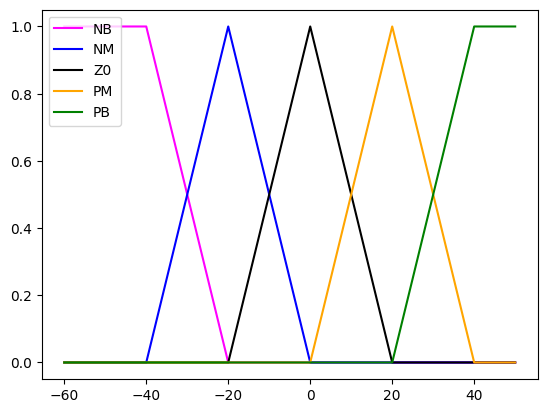

In [28]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
 
# 速度偏差のメンバーシップ関数を描画する
dv = np.array([-60, -40, -20, 0, 20, 40, 50])

nb = np.array([1, 1, 0, 0, 0, 0, 0])
plt_nb = plt.plot(dv, nb, color="magenta")

nm = np.array([0, 0, 1, 0, 0, 0, 0])
plt_nm = plt.plot(dv, nm, color="blue")

z0 = np.array([0, 0, 0, 1, 0, 0, 0])
plt_z0 = plt.plot(dv, z0, color="black")

pm = np.array([0, 0, 0, 0, 1, 0, 0])
plt_pm = plt.plot(dv, pm, color="orange")

pb = np.array([0, 0, 0, 0, 0, 1, 1])
plt_pb = plt.plot(dv, pb, color="green")

plt.legend((plt_nb[0], plt_nm[0], plt_z0[0], plt_pm[0], plt_pb[0]), ("NB", "NM", "Z0", "PM", "PB"), loc=2)

# Shift + Enter を押してもメンバーシップ関数のグラフが表示されないときには，もう一度 Shift + Enter を押す

### 後件部 加速の大きさに対応する三角型メンバーシップ関数

加速の大きさに対応する三角型メンバーシップ関数は以下の形です．

メンバーシップ関数のグラフが見えない場合には，pythonのコードが書かれているセルで，`Shift + Enter` を押してください．

ファジィラベルは以下のことを意味します．

- NB：強いブレーキ
- NM：弱いブレーキ
- Z0：加速しない
- PM：弱いアクセル
- PB：強いアクセル

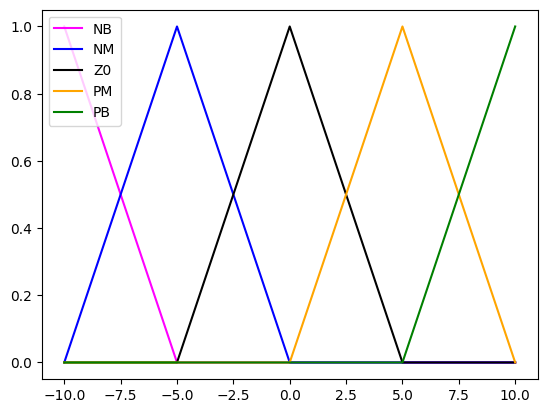

In [29]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
 
# 加速の大きさのメンバーシップ関数を描画する
accel = np.array([-10, -5, 0, 5, 10])

nb = np.array([1, 0, 0, 0, 0])
plt_nb = plt.plot(accel, nb, color="magenta")

nm = np.array([0, 1, 0, 0, 0])
plt_nm = plt.plot(accel, nm, color="blue")

z0 = np.array([0, 0, 1, 0, 0])
plt_z0 = plt.plot(accel, z0, color="black")

pm = np.array([0, 0, 0, 1, 0])
plt_pm = plt.plot(accel, pm, color="orange")

pb = np.array([0, 0, 0, 0, 1])
plt_pb = plt.plot(accel, pb, color="green")

plt.legend((plt_nb[0], plt_nm[0], plt_z0[0], plt_pm[0], plt_pb[0]), ("NB", "NM", "Z0", "PM", "PB"), loc=2)

# Shift + Enter を押してもメンバーシップ関数のグラフが表示されないときには，もう一度 Shift + Enter を押す

### ファジィルール

車の速度制御におけるファジィルールは以下の11個です．

1. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 遅すぎる(NB)" then "加速の大きさ is 強いアクセル(PB)"
2. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is やや遅い(NM)" then "加速の大きさ is 弱いアクセル(PM)"
3. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 適度(Z0)" then "加速の大きさ is 加速しない(Z0)"
4. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is やや速い(PM)" then "加速の大きさ is 弱いブレーキ(NM)"
5. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 速すぎる(PB)" then "加速の大きさ is 強いブレーキ(NB)"
6. if "道路の勾配 is 下り坂(N)" and "速度偏差 is やや速い(PM)" then "加速の大きさ is 強いブレーキ(NB)"
7. if "道路の勾配 is 下り坂(N)" and "速度偏差 is 適度(Z0)" then "加速の大きさ is 弱いブレーキ(NM)"
8. if "道路の勾配 is 下り坂(N)" and "速度偏差 is やや遅い(NM)" then "加速の大きさ is 加速しない(Z0)"
9. if "道路の勾配 is 上り坂(P)" and "速度偏差 is やや速い(PM)" then "加速の大きさ is 加速しない(Z0)"
10. if "道路の勾配 is 上り坂(P)" and "速度偏差 is 適度(Z0)" then "加速の大きさ is 弱いアクセル(PM)"
11. if "道路の勾配 is 上り坂(P)" and "速度偏差 is やや遅い(NM)" then "加速の大きさ is 強いアクセル(PB)"

## ファジィ制御の実装

### 前件部 道路の勾配のメンバーシップ値を求める関数を作る

In [30]:
def mf_of_slope(x):
    """ 道路の勾配（-1から1の値）から，対応する各ファジィ集合（N，Z0，P）のメンバーシップ値を計算する．
    
    Args:
        x: 道路の勾配．-1から1の値を取る．
        
    Returns:
        辞書型の戻り値．keyは各ファジィ集合のラベル，valueは引数xに対する各ファジィ集合（N，Z0，P）のメンバーシップ値．
    
    """
    
    # 変数を初期化する
    n = z0 = p = None
        
    ## nに対するメンバーシップ値
    n = -x if x < 0.0 else 0.0
    
    ## z0に対するメンバーシップ値
    z0 = x + 1.0 if x <= 0.0 else -x + 1.0
    
    ## pに対するメンバーシップ値
    p = 0.0 if x <= 0.0 else x
    
    return {'n':n, 'z0':z0, 'p':p}

# プログラムが書けたら，Shift + Enter でプログラムを実行する

In [31]:
# 道路の勾配に対して，メンバーシップ値が正しく求められているかを確認する
slope = mf_of_slope(0.0)

print("道路の勾配に対するメンバーシップ値")
print("ファジィラベル N ： ", slope['n']) # 辞書型変数はキー指定で値を参照できる
print("ファジィラベル Z0 ： ", slope['z0'])
print("ファジィラベル P ： ", slope['p'])

道路の勾配に対するメンバーシップ値
ファジィラベル N ：  0.0
ファジィラベル Z0 ：  1.0
ファジィラベル P ：  0.0


### 課題(1) 前件部 速度偏差のメンバーシップ値を求める関数を作る

In [32]:
def mf_of_dv(x):
    """ 速度偏差（-60から50の値）から，対応する各ファジィ集合（NB，NM，Z0，PM，PB)のメンバーシップ値を計算する．
    
    Args:
        x: 速度偏差．-60から50の値を取る．
        
    Returns:
        辞書型の戻り値．keyは各ファジィ集合のラベル，valueは引数xに対する各ファジィ集合（NB，NM，Z0，PM，PB）のメンバーシップ値．
    
    """
    
    # 変数を初期化する
    nb = nm = z0 = pm = pb = None
    
    # ここに各メンバーシップ関数の値を計算する処理を書く
    # 無理に三項演算子を使わなくてもOK．自分がわかる書き方で書きましょう
    
    # nbに対するメンバーシップ値
    "ここを自分で書く"
    nb = 1.0 if x <= -40 else 0.0 if x >= -20 else (-0.05 * x - 1.0)
    # nmに対するメンバーシップ値
    "ここを自分で書く"
    nm = 0.0 if x <= -40 else (0.05 * x + 2.0)if x <= -20 else (-0.05 * x) if x <= 0 else 0.0
    # z0に対するメンバーシップ値
    "ここを自分で書く"
    z0 = 0.0 if x <= -20 else (0.05 * x + 1.0) if x <= 0 else (-0.05 * x) + 1.0 if x <= 20 else 0.0
    # pmに対するメンバーシップ値
    "ここを自分で書く"
    pm = 0.0 if x <= 0 else (0.05 * x) if x <= 20 else (-0.05 * x + 2.0) if x <= 40 else 0.0
    # pbに対するメンバーシップ値
    "ここを自分で書く"
    pb = 0.0 if x <= 20 else (0.05 * x - 1.0) if x <= 40 else 1.0
    
    return {'nb':nb, 'nm':nm, 'z0':z0, 'pm':pm, 'pb':pb}

# Shift + Enter でプログラムを実行する

In [33]:
# 速度偏差に対して，メンバーシップ値が正しく求められているかを確認する
# dv = mf_of_dv("ここに速度偏差を表す数値を入れる")
dv = mf_of_dv(40)

print("速度偏差に対するメンバーシップ値")
print("ファジィラベル NB ： ", dv['nb']) # 辞書型変数はキー指定で値を参照できる
print("ファジィラベル NM ： ", dv['nm'])
print("ファジィラベル Z0 ： ", dv['z0'])
print("ファジィラベル PM ： ", dv['pm'])
print("ファジィラベル PB ： ", dv['pb'])

速度偏差に対するメンバーシップ値
ファジィラベル NB ：  0.0
ファジィラベル NM ：  0.0
ファジィラベル Z0 ：  0.0
ファジィラベル PM ：  0.0
ファジィラベル PB ：  1.0


### 課題(2) 後件部 加速の大きさに対応するメンバーシップ値を求める関数を作る

In [34]:
def mf_of_accel(x):
    """ 加速の大きさ（-10から10の値）から，対応する各ファジィ集合（NB，NM，Z0，PM，PB）のメンバーシップ値を計算する．
    
    Args:
        x: 加速の大きさ．-10から10の値を取る．
        
    Returns:
        辞書型の戻り値．keyは各ファジィ集合のラベル，valueは引数xに対する各ファジィ集合（NB，NM，Z0，PM，PB）のメンバーシップ値．
    
    """
    
    # 変数を初期化する
    nb = nm = z0 = pm = pb = None
    
    # ここに各メンバーシップ関数の値を計算する処理を書く
    # 無理に三項演算子を使わなくてもOK．自分がわかる書き方で書きましょう
    
    # nbに対するメンバーシップ値
    "ここを自分で書く"
    nb = 1.0 if x <= -10 else (-0.2 * x - 1.0) if x <= -5 else 0.0

    nm = 0.0 if x < -10 else (0.2 * x + 2.0) if x <= -5 else (-0.2 * x) if x <= 0 else 0.0

    z0 = 0.0 if x < -5 else (0.2 * x + 1.0) if x <= 0 else (-0.2 * x + 1.0) if x <= 5 else 0.0

    pm = 0.0 if x <= 0 else (0.2 * x) if x <= 5 else (-0.2 * x + 2.0) if x <= 10 else 0.0

    pb = 0.0 if x <= 5 else (0.2 * x - 1.0) if x <= 10 else 1.0

    return {'nb':nb, 'nm':nm, 'z0':z0, 'pm':pm, 'pb':pb}

# Shift + Enter でプログラムを実行する

In [35]:
# 加速の大きさに対して，メンバーシップ値が正しく求められているかを確認する
# acc = mf_of_accel("ここに加速の大きさを表す数値を入れる")
acc = mf_of_accel(0.2)

print("加速の大きさに対するメンバーシップ値")
print("ファジィラベル NB ： ", acc['nb']) # 辞書型変数はキー指定で値を参照できる
print("ファジィラベル NM ： ", acc['nm'])
print("ファジィラベル Z0 ： ", acc['z0'])
print("ファジィラベル PM ： ", acc['pm'])
print("ファジィラベル PB ： ", acc['pb'])

加速の大きさに対するメンバーシップ値
ファジィラベル NB ：  0.0
ファジィラベル NM ：  0.0
ファジィラベル Z0 ：  0.96
ファジィラベル PM ：  0.04000000000000001
ファジィラベル PB ：  0.0


ここまで，

- 前件部 道路の勾配に対応するメンバーシップ値を求める関数 `mf_of_slope()`
- 前件部 速度偏差に対応するメンバーシップ値を求める関数 `mf_of_dv()`
- 後件部 加速の大きさに対応するメンバーシップ値を求める関数 `mf_of_accel()`

の3つを実装できましたでしょうか．

### 各ファジィルールの結論を求めるために，後件部を離散化する

後件部の離散化は `sc2025-sample.ipynb` と同じですが，今後のために関数にしておきます．

In [36]:
# numpyをインポートし，npという名前で扱えるようにする
import numpy as np

def descretize():
    """ 後件部のファジィ集合を離散化する
    
    Args:
        なし
        
    Returns:
        辞書型の戻り値．keyは各ファジィ集合のラベル，valueは引数xに対する各ファジィ集合（NB，NM，Z0，PM，PB）のメンバーシップ値．
    
    """

    # 各ファジィ集合のメンバーシップ値を格納するnumpy配列を初期化する
    # 101なのは，要素である加速の大きさを0.2刻みの値で扱うため
    nb = np.zeros(101)
    nm = np.zeros(101)
    z0 = np.zeros(101)
    pm = np.zeros(101)
    pb = np.zeros(101)

    # 加速の大きさを0.2刻みでnumpy配列として用意する
    accel_support =  np.arange(-10, 10.2, 0.2)

    # 加速の大きさのファジィ集合に対応するnumpy配列に，メンバーシップ値を格納する
    for i in range(101):
        nb[i] = mf_of_accel(accel_support[i])['nb']
        nm[i] = mf_of_accel(accel_support[i])['nm']
        z0[i] = mf_of_accel(accel_support[i])['z0']
        pm[i] = mf_of_accel(accel_support[i])['pm']
        pb[i] = mf_of_accel(accel_support[i])['pb']

    # 今後のために辞書型の変数に格納しておく
    return({'nb':nb, 'nm':nm, 'z0':z0, 'pm':pm, 'pb':pb})

In [37]:
# 各ファジィ集合にメンバーシップ値が格納されたかの確認

# 指数表記をしないための設定
np.set_printoptions(suppress=True)

accel = descretize()

# 辞書型の変数にしておくことで，ファジィ集合名で値を返すことができる
print("ファジィ集合 nb")
print(accel['nb'])

print("ファジィ集合 nm")
print(accel['nm'])

print("ファジィ集合 z0")
print(accel['z0'])

print("ファジィ集合 pm")
print(accel['pm'])

print("ファジィ集合 pb")
print(accel['pb'])

ファジィ集合 nb
[1.   0.96 0.92 0.88 0.84 0.8  0.76 0.72 0.68 0.64 0.6  0.56 0.52 0.48
 0.44 0.4  0.36 0.32 0.28 0.24 0.2  0.16 0.12 0.08 0.04 0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.  ]
ファジィ集合 nm
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   0.96 0.92
 0.88 0.84 0.8  0.76 0.72 0.68 0.64 0.6  0.56 0.52 0.48 0.44 0.4  0.36
 0.32 0.28 0.24 0.2  0.16 0.12 0.08 0.04 0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.

### 各ファジィルールについて，結論を求める

1つのファジィルールから結論を求める関数は，`sc2025-sample.ipynb`で定義したものをそのまま使います．

In [38]:
def rule(*args, arg1):
    """ ひとつのファジィルールについて，結論を求める．
    
    Args:
        *args: ファジィルール前件部のメンバーシップ値．可変長引数という仕組みを使っていて，引数をいくつでも与えることができる．
        arg1: ファジィルール後件部の離散化したファジィ集合．引数の最後は必ず後件部のファジィ集合でなければいけない．
        
    Returns:
        結論のメンバーシップ値をnumpy配列で返す．
    
    """
    
    # 前件部のメンバーシップ値のandを取る．入力は確定値なので，値が1つ得られる．
    # antecedent は前件部という意味
    # args には，引数として与えた前件部のファジィ集合がすべて含まれている
    antecedent = min(args)
    
    # antecedentと後件部とでandをとった結果が結論となる
    # arg1 は，引数として与えた後件部のファジィ集合（numpy配列）
    # np.where()を使うことで，antecedentと後件部numpy配列のandを取れる（もちろん，forループなど使って地道に書いてもよい）
    result = np.where(arg1 <= antecedent, arg1, antecedent)
    
    return result

# Shift + Enter で実行する

### 課題(3) ファジィルールを与えて結論を求める

ここでは，以下の5つファジィルールを与えて，各ルールに対する結論を求めてみましょう．

1. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 遅すぎる(NB)" then "加速の大きさ is 強いアクセル(PB)"
2. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is やや遅い(NM)" then "加速の大きさ is 弱いアクセル(PM)"
3. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 適度(Z0)" then "加速の大きさ is 加速しない(Z0)"
4. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is やや速い(PM)" then "加速の大きさ is 弱いブレーキ(NM)"
5. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 速すぎる(PB)" then "加速の大きさ is 強いブレーキ(NB)"

ここまで，変数名を書き換えていなければ，道路の勾配は`slope`，速度偏差は`dv`，加速の大きさは`accel`という名前の変数にしているはずです．

入力となる，道路の勾配の値，速度偏差の値は以下のようにしてください．

- 道路の勾配は 0.2
- 速度偏差は -30 （目標60km/hよりも30km/h遅い） 

In [39]:
# 道路の勾配のメンバーシップ値を求める
slope = mf_of_slope(0.2)
# 速度偏差のメンバーシップ値を求める
dv = mf_of_dv(-30)

# 各ファジィルールの結論を求める
# 1. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 遅すぎる(NB)" then "加速の大きさ is 強いアクセル(PB)"
rule1 = rule(slope["z0"], dv["nb"], arg1=accel["pb"])

# 2. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is やや遅い(NM)" then "加速の大きさ is 弱いアクセル(PM)"
rule2 = rule(slope["z0"], dv["nm"], arg1=accel["pm"])

# 3. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 適度(Z0)" then "加速の大きさ is 加速しない(Z0)"
rule3 = rule(slope["z0"], dv["z0"], arg1=accel["z0"])

# 4. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is やや速い(PM)" then "加速の大きさ is 弱いブレーキ(NM)"
rule4 = rule(slope["z0"], dv["pm"], arg1=accel["nm"])

# 5. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 速すぎる(PB)" then "加速の大きさ is 強いブレーキ(NB)
rule5 = rule(slope["z0"], dv["pb"], arg1=accel["nb"])


# 各結論を表示して確認する
print("rule1:")
print(rule1)

print("rule2:")
print(rule2)

print("rule3:")
print(rule3)

print("rule4:")
print(rule4)

print("rule5:")
print(rule5)

rule1:
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32
 0.36 0.4  0.44 0.48 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5 ]
rule2:
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.08 0.12 0.16 0.2
 0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.5  0.5  0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5  0.5  0.48 0.44 0.4  0.36 0.32 0.28 0.24 0.2  0.16 

### 課題(4) 各ファジィルールの結論をまとめる

`sc2025-sample.ipynb`を参考し，上記5つのファジィルールの結論をまとめてください．

In [40]:
# 各ファジィルールの結論をまとめる（OR結合する）
result = np.maximum.reduce([rule1, rule2, rule3, rule4, rule5])

# OR結合でまとめた結論を表示する
print('OR結合の結果')
print(result)

OR結合の結果
[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.08 0.12 0.16 0.2
 0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.5  0.5  0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5 ]


### 課題(5) 非ファジィ化して，出力する値を求める

`sc2025-sample.ipynb`を参考にし，非ファジィ化する関数 `defuzzy()` を完成させてください．

In [41]:
def defuzzy(fs):
    """ 結論として求められたファジィ集合に対して，非ファジィ化を行う．重心法で計算する．
    Args:
        fs: 各結論をOR結合して求められた結論．numpy配列で与えられる．
        
    Returns:
        重心法で非ファジィ化した値
    
    """

    num = 0.0
    den = 0.0
    size = -10.0 # 加速の大きさを表す．以下のforループで0.2刻みで増えていく
    
    for x in fs:
        num = num + x * size
        den = den + x
        size = size + 0.2
     
    center = num / den if den != 0.0 else 0.0

    return center

In [42]:
# 各結論をOR結合したファジィ集合を表示する
print(result)

# 非ファジィ化した値を求める
result_defuzzy = defuzzy(result)

print("非ファジィ化した結果：")
print(result_defuzzy)

[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.04 0.08 0.12 0.16 0.2
 0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.5  0.5  0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5  0.5
 0.5  0.5  0.5 ]
非ファジィ化した結果：
5.64647377938519


非ファジィ化した結果が`5.64647377938519`になっていれば，正しくプログラムを書けています．

## ファジィ制御で目標速度で走行できるかを確認する

ここまでのプログラムでは，1回の入力に対してファジィ制御で出力値を求めているだけです．

ということで，本当にファジィ制御によって目標速度で走行できるかどうかを確かめてみましょう．

道路の勾配を表す変数（配列）を追加します．

これはみなさんがプログラムを書く必要はないので，次のセルのプログラムを`Shift+Enter`で実行してください．

In [43]:
# 道路の勾配を表すためのnumpy配列を用意する
import numpy as np

# np.zeros()で初期値0の配列を作る．配列のサイズは1000
road = np.zeros(1000)

# 配列のインデックスが時刻を表すことにする

# 時刻0から299までは，平坦な道．つまり，road[0]からroad[299]までは0のまま．

# 時刻300から499までは，上り坂
road[300:350] = 0.5
road[350:400] = 0.6
road[400:500] = 0.2

# 時刻500から599までは，平坦な道．つまり，road[500]からroad[599]までは0のまま．

# 時刻600から899までは，下り坂
road[600:700] = -0.3
road[700:800] = -0.4
road[800:850] = -0.2
road[850:900] = -0.1

# 時刻900から999までは，平坦な道．つまり，road[900]からroad[999]までは0のまま

# 現実的な値でないですが，気にしないでください

### 課題(6) 時刻0から999まで，ファジィ制御を繰り返して，車の速度を制御する

ファジィ制御を繰り返し行って，車の速度を制御してみましょう．

以下のセルに必要な処理を記述して，実行してみてください．

必要な関数はすでに定義・実行しているはずなので，以下のセルに関数を追記する必要はありません．もし関数まわりでエラーが出る場合には，ノートブックの一番上のセルから順番に実行し直すとよいでしょう．

In [44]:
# 指数表記をしないための設定
np.set_printoptions(suppress=True)

# 目標速度は60.0km/h
vs = 60.0

# param はファジィ制御の状態を保持する変数．辞書型.
    # キー slope は時刻tにおける道路の勾配．値はnumpy配列．
    # キー dv は時刻tにおける速度偏差．値はnumpy配列．
    # キー accel は時刻tにおける加速の大きさ．値はnumpy配列．
    # キー v は時刻tにおける現在速度．値はnumpy配列．
param = {'slope':np.zeros(1000), 'dv':np.zeros(1000),  'accel':np.zeros(1000), 'v':np.zeros(1000)}

# 時刻t=0での速度偏差をparamに代入しておく
param['dv'][0] = param['v'][0] - vs

# 初期状態を表示する
print("t, slope, dv, accel, v")
print(0, param['slope'][0], param['dv'][0], param['accel'][0], param['v'][0], sep=', ')

# ここから，ファジィ制御
for t in range(1, 1000): # 変数tに，1から999までの数が順番に代入される．変数tは時刻を表す．
    # 後件部ファジィ集合を離散化する
    accel = descretize()
    # 道路の勾配と，速度偏差から，前件部のファジィ集合に対するメンバーシップ値を求める
    slope = mf_of_slope(road[t]) # 道路の勾配は配列road[]に格納されている
    
    dv = mf_of_dv(param['dv'][t-1]) # 時刻 t-1 のときの速度偏差を見る

    # 各ファジィルールについて，結論を求める
    # 1. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 遅すぎる(NB)" then "加速の大きさ is 強いアクセル(PB)"
    rule1 = rule(slope["z0"], dv["nb"], arg1=accel["pb"])
    # 2. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is やや遅い(NM)" then "加速の大きさ is 弱いアクセル(PM)"
    rule2 = rule(slope["z0"], dv["nm"], arg1=accel["pm"])
    # 3. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 適度(Z0)" then "加速の大きさ is 加速しない(Z0)"
    rule3 = rule(slope["z0"], dv["z0"], arg1=accel["z0"])
    # 4. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is やや速い(PM)" then "加速の大きさ is 弱いブレーキ(NM)"
    rule4 = rule(slope["z0"], dv["pm"], arg1=accel["nm"])
    # 5. if "道路の勾配 is 平坦(Z0)" and "速度偏差 is 速すぎる(PB)" then "加速の大きさ is 強いブレーキ(NB)
    rule5 = rule(slope["z0"], dv["pb"], arg1=accel["nb"])
    # 6. if "道路の勾配 is 下り坂(N)" and "速度偏差 is やや速い(PM)" then "加速の大きさ is 強いブレーキ(NB)"
    rule6 = rule(slope["n"], dv["pm"], arg1=accel["nb"])
    # 7. if "道路の勾配 is 下り坂(N)" and "速度偏差 is 適度(Z0)" then "加速の大きさ is 弱いブレーキ(NM)"
    rule7 = rule(slope["n"], dv["z0"], arg1=accel["nm"])
    # 8. if "道路の勾配 is 下り坂(N)" and "速度偏差 is やや遅い(NM)" then "加速の大きさ is 加速しない(Z0)"
    rule8 = rule(slope["n"], dv["nm"], arg1=accel["z0"])
    # 9. if "道路の勾配 is 上り坂(P)" and "速度偏差 is やや速い(PM)" then "加速の大きさ is 加速しない(Z0)"
    rule9 = rule(slope["p"], dv["pm"], arg1=accel["z0"])
    # 10. if "道路の勾配 is 上り坂(P)" and "速度偏差 is 適度(Z0)" then "加速の大きさ is 弱いアクセル(PM)"
    rule10 = rule(slope["p"], dv["z0"], arg1=accel["pm"])
    # 11. if "道路の勾配 is 上り坂(P)" and "速度偏差 is やや遅い(NM)" then "加速の大きさ is 強いアクセル(PB)"
    rule11 = rule(slope["p"], dv["nm"], arg1=accel["pb"])
    # 各ファジィルールの結論をまとめる（OR結合する）
    result = np.maximum.reduce([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11])
    # 非ファジィ化する．これが結論として求められた加速の大きさとなる．
    result_defuzzy = defuzzy(result)
    
    # 現在の状態をparamに格納する
    param['slope'][t] = road[t]
    param['accel'][t] = result_defuzzy
    param['v'][t] = param['v'][t-1] + param['accel'][t]
    param['dv'][t] = param['v'][t] - vs
    
    # 現在の状態を表示する
    print(t, param['slope'][t], param['dv'][t], param['accel'][t], param['v'][t], sep=', ')


t, slope, dv, accel, v
0, 0.0, -60.0, 0.0, 0.0
1, 0.0, -51.59999999999999, 8.400000000000015, 8.400000000000015
2, 0.0, -43.199999999999974, 8.400000000000015, 16.80000000000003
3, 0.0, -34.799999999999955, 8.400000000000015, 25.200000000000045
4, 0.0, -28.306263498920046, 6.493736501079907, 31.693736501079954
5, 0.0, -22.85701462115194, 5.449248877768108, 37.14298537884806
6, 0.0, -17.79262524104312, 5.064389380108819, 42.20737475895688
7, 0.0, -13.518178388320806, 4.274446852722314, 46.481821611679194
8, 0.0, -10.29659499539904, 3.2215833929217634, 49.70340500460096
9, 0.0, -7.737257008163269, 2.559337987235768, 52.26274299183673
10, 0.0, -5.694618112241621, 2.04263889592165, 54.30538188775838
11, 0.0, -4.088969838688698, 1.6056482735529194, 55.9110301613113
12, 0.0, -2.8601687922097057, 1.2288010464789911, 57.139831207790294
13, 0.0, -1.9508048302226015, 0.9093639619871049, 58.0491951697774
14, 0.0, -1.3009696239910795, 0.6498352062315236, 58.69903037600892
15, 0.0, -0.8517713023349

`param`の内容をテキストで表示しただけではわかりにくいので，以下のセルを実行してグラフを描画しましょう．

グラフが表示されない場合はもう一度実行してください．

Text(0, 0.5, 'accel')

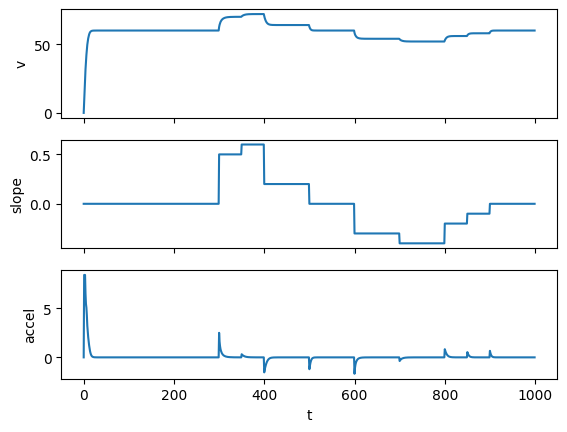

In [45]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

t = np.arange(0, 1000)

fig, axes = plt.subplots(3, 1, sharex=True)
axes[0].plot(t, param['v'])
axes[1].plot(t, param['slope'])
axes[2].plot(t, param['accel'])

axes[2].set_xlabel('t')

axes[0].set_ylabel('v')
axes[1].set_ylabel('slope')
axes[2].set_ylabel('accel')


描画したグラフは上から，現在速度，道路の勾配，加速の大きさ，です．

moodleの課題の説明のページに，正解のグラフ画像を載せています．

正解のグラフと同じようなグラフになっていればプログラムは正しく書けているはずです．

もし同じようなグラフにならない場合は，ノートブックのセルを一番上から実行し直してみてください．セルの実行順序が影響し，想定どおりの出力になっていない可能性があります．

それでもだめなら，プログラムに間違いがないかを確認してください．

プログラムが完成したら，このノートブックを保存して各自のPCにダウンロードし，moodleでノートブックのファイルを提出してください．